# init

In [1]:
import os
import sys
import copy
import glob
import numpy as np
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
import pickle
from scipy import stats
import importlib
import time
import tifffile as tf
import shutil
from matplotlib.backends.backend_pdf import PdfPages
plt.rcParams['font.family']           = 'sans-serif'
plt.rcParams['font.sans-serif']       = ['Arial']
plt.rcParams['pdf.fonttype']          = 42       # embed fonts in PDF (Type 42)
plt.rcParams['axes.unicode_minus']    = False    # use ASCII minus sign
plt.rcParams['mathtext.default']      = 'regular'

#IMPORTANT two options for setting paths here:
#OPTION 1: Automatically determine the parent directory of the notebook's directory
# import ipynbname
# NOTEBOOK_PATH = ipynbname.path()
# PARENT_DIR = NOTEBOOK_PATH.parent.parent  # parent of the notebook's directory
# print("NOTEBOOK_PATH: " + str(NOTEBOOK_PATH))
# print("PARENT_DIR: " + str(PARENT_DIR))
#OPTION 2: Manually set PARENT_DIR if needed
PARENT_DIR = "/home/range6-raid17/kerlinlab/sled/sled-klab/manuscripts/Scheib2026/VOR"
DATA_DIR = "/export/general/pooledData/Jackson/repo_data/"
figSaveDir = os.path.join(PARENT_DIR, "figurePanels", "Fig2")
PDF_export_active = False

#IMPORTANT: The following class and function are used to conditionally save figures to PDF based on the PDF_export_active flag. If PDF_export_active is True, figures will be saved to the specified path; if False, the savefig calls will be ignored.
class _NoPdf:
    """Null stand-in for PdfPages: accepts savefig calls and writes nothing."""
    def __enter__(self):        return self
    def __exit__(self, *exc):   return False
    def savefig(self, *args, **kwargs): pass

def maybe_pdf(path, active=None):
    active = PDF_export_active if active is None else active
    return PdfPages(path) if active else _NoPdf()

#IMPORTANT Load the manuscript functions
import js_manuscript_final as jsm

#OPTIONAL Load from specific directory if needed (uncomment the following lines)
# path = os.path.join(PARENT_DIR, "js_manuscript_final.py")
# spec = importlib.util.spec_from_file_location("jsm", path)
# jsm = importlib.util.module_from_spec(spec)
# spec.loader.exec_module(jsm)
# print(jsm.__file__)

#OPTIONAL Reload the module to ensure the latest version is used
%load_ext autoreload
%autoreload 2

In [2]:
# Load everything saved above and reconstruct the exact variables image_and_trace_movie_preview() needs,
# without re-running the rest of the notebook (no summaryInfo/data/imageData imports required). The
# trimmed trace arrays and imageData frames saved above only ever recorded the cells/frames that were
# actually read/rendered; here each one is scattered back into an empty full-shape array at those same
# positions so data[anat]['sessions'][sess][key][ROI, importFrs] and imageData[ch]['data'][f,:,:] index
# correctly again inside collect_plot_traces() / image_and_trace_movie_preview().
################################################################################
def _resolve(entry,paramsDir):
    if isinstance(entry,dict) and set(entry.keys())=={'__file__'}:
        with open(os.path.join(paramsDir,entry['__file__']),'rb') as f:
            return pickle.load(f)
    return entry
################################################################################
def _restore_trace(entry):
    fillVal = np.nan if np.issubdtype(entry['dtype'],np.floating) else 0
    fullArr = np.full(entry['shape'],fillVal,dtype=entry['dtype'])
    fullArr[np.ix_(entry['ROIs'],entry['importFrs'])] = entry['trimmed']
    return fullArr
################################################################################
def _restore_licks(entry):
    dtype0,dtype1 = entry['trimmed'][0].dtype,entry['trimmed'][1].dtype
    fill0 = np.nan if np.issubdtype(dtype0,np.floating) else 0
    fill1 = np.nan if np.issubdtype(dtype1,np.floating) else 0
    licks_full = [np.full(entry['nFrames_total'],fill0,dtype=dtype0),np.full(entry['nFrames_total'],fill1,dtype=dtype1)]
    licks_full[0][entry['importFrs']] = entry['trimmed'][0]
    licks_full[1][entry['importFrs']] = entry['trimmed'][1]
    return licks_full
################################################################################
def _restore_image_frames(entry):
    fullArr = np.full(entry['shape'],np.nan,dtype=entry['dtype'])
    fullArr[entry['frameIdxs'],:,:] = entry['trimmed']
    return fullArr
################################################################################


Loaded movie preview params for: B00002213784 230123 Day-6 Sess0 L1_Dend 4 | Tr 21CL 22CR


/home/range6-raid17/kerlinlab/sled/sled-klab/manuscripts/Scheib2026/functions/js_manuscript_final.py:14480: UserWarning: This figure was using a layout engine that is incompatible with subplots_adjust and/or tight_layout; not calling subplots_adjust.
  plt.subplots_adjust(wspace=0, hspace=0)


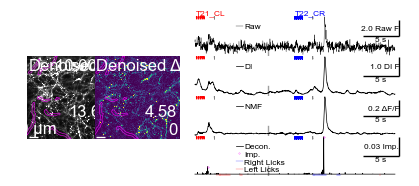

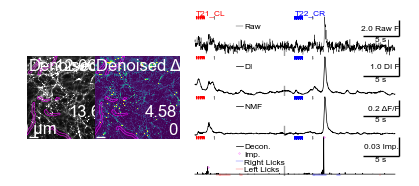

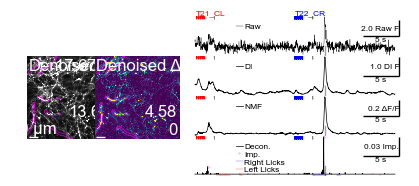

In [3]:
################################################################################################################################################################
################################################################################################################################################################
load_saveName = "B00002213784_230123_Day-6_Sess0_L1_Dend_4_Tr_21CL_22CR"  # base filename printed by the save cell
paramsDir = os.path.join(DATA_DIR,'examples','fig2_indiv_examples')
################################################################################
indexPath = os.path.join(paramsDir,load_saveName+"_movie_preview_index.pkl")
with open(indexPath,'rb') as indexFile:
    movie_preview_index = pickle.load(indexFile)
################################################################################
movie_preview_loaded = {}
for name,val in movie_preview_index.items():
    if name == 'imageData':
        movie_preview_loaded['imageData'] = {}
        for ch,chEntry in val.items():
            chData = _resolve(chEntry,paramsDir)
            chData_restored = {}
            for k,v in chData.items():
                if k == 'data' and isinstance(v,dict) and 'trimmed' in v:
                    chData_restored[k] = _restore_image_frames(v)
                else:
                    chData_restored[k] = v
            movie_preview_loaded['imageData'][ch] = chData_restored
    else:
        movie_preview_loaded[name] = _resolve(val,paramsDir)
################################################################################
# Reconstruct `data` by scattering the trimmed trace arrays back into empty full-shape arrays
data_simple = movie_preview_loaded['data']
data = {}
for anatKey,anatVal in data_simple.items():
    data[anatKey] = {'sessions': {}}
    for sessKey,sessVal in anatVal['sessions'].items():
        data[anatKey]['sessions'][sessKey] = {}
        for key,entry in sessVal.items():
            if key == 'licks_per_fr':
                data[anatKey]['sessions'][sessKey][key] = _restore_licks(entry)
            else:
                data[anatKey]['sessions'][sessKey][key] = _restore_trace(entry)
################################################################################
# Unpack the rest of image_and_trace_movie_preview()'s arguments into notebook variables
saveName = load_saveName
anat = movie_preview_loaded['anat']
sess = movie_preview_loaded['sess']
traceKeys = movie_preview_loaded['traceKeys']
imageData = movie_preview_loaded['imageData']
imageParams = movie_preview_loaded['imageParams']
cropParams = movie_preview_loaded['cropParams']
movieParams = movie_preview_loaded['movieParams']
importFrs = movie_preview_loaded['importFrs']
ROIs = movie_preview_loaded['ROIs']
ROI_borders = movie_preview_loaded['ROI_borders']
ROI_colors = movie_preview_loaded['ROI_colors']
plotParams = movie_preview_loaded['plotParams']
trial_details = movie_preview_loaded['trial_details']
auto_frames = movie_preview_loaded['auto_frames']
saveName1 = movie_preview_loaded['saveName1']
eventFrame = movie_preview_loaded['eventFrame']
saveFig = movie_preview_loaded['saveFig']
cleanFig = movie_preview_loaded['cleanFig']
print("Loaded movie preview params for: "+saveName1)
################################################################################
# Re-run the preview exactly like the original cell (movieParams['previewPDFDir'] must still exist/be set)
with maybe_pdf(os.path.join(movieParams['previewPDFDir'],saveName+"_auto_frames.pdf")) as pdf:
    for ft in auto_frames.keys():
        pdf = jsm.image_and_trace_movie_preview(pdf,data,anat,sess,traceKeys,imageData,imageParams,cropParams,movieParams,\
              importFrs,ROIs,ROI_borders,ROI_colors,plotParams,trial_details,int(auto_frames[ft]),saveName1,eventFrame,saveFig,cleanFig)

Loaded movie preview params for: B00002213784 230124 Day-5 Sess0 L5_Soma 33 | Tr 270CR 271CL


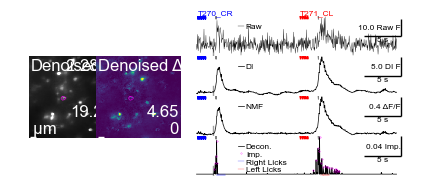

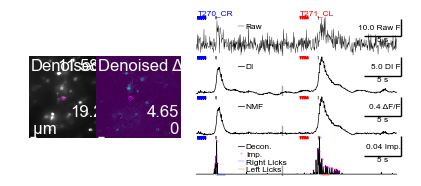

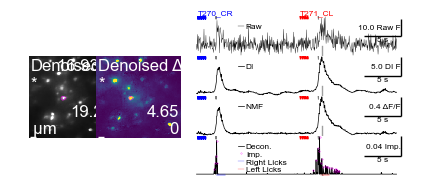

In [4]:
################################################################################################################################################################
################################################################################################################################################################
# Load everything saved above and reconstruct the exact variables image_and_trace_movie_preview() needs,
# without re-running the rest of the notebook (no summaryInfo/data/imageData imports required). The
# trimmed trace arrays saved above only ever recorded the [ROI, importFrs] cells that were actually read;
# here each one is scattered back into an empty full-shape array at those same positions so
# data[anat]['sessions'][sess][key][ROI, importFrs] indexes correctly again inside collect_plot_traces().
load_saveName = "B00002213784_230124_Day-5_Sess0_L5_Soma_33_Tr_270CR_271CL"  # base filename printed by the save cell
paramsDir = os.path.join(DATA_DIR,'examples','fig2_indiv_examples')
################################################################################
indexPath = os.path.join(paramsDir,load_saveName+"_movie_preview_index.pkl")
with open(indexPath,'rb') as indexFile:
    movie_preview_index = pickle.load(indexFile)
################################################################################
movie_preview_loaded = {}
for name,val in movie_preview_index.items():
    if name == 'imageData':
        movie_preview_loaded['imageData'] = {}
        for ch,chEntry in val.items():
            chData = _resolve(chEntry,paramsDir)
            chData_restored = {}
            for k,v in chData.items():
                if k == 'data' and isinstance(v,dict) and 'trimmed' in v:
                    chData_restored[k] = _restore_image_frames(v)
                else:
                    chData_restored[k] = v
            movie_preview_loaded['imageData'][ch] = chData_restored
    else:
        movie_preview_loaded[name] = _resolve(val,paramsDir)
################################################################################
# Reconstruct `data` by scattering the trimmed trace arrays back into empty full-shape arrays
data_simple = movie_preview_loaded['data']
data = {}
for anatKey,anatVal in data_simple.items():
    data[anatKey] = {'sessions': {}}
    for sessKey,sessVal in anatVal['sessions'].items():
        data[anatKey]['sessions'][sessKey] = {}
        for key,entry in sessVal.items():
            if key == 'licks_per_fr':
                data[anatKey]['sessions'][sessKey][key] = _restore_licks(entry)
            else:
                data[anatKey]['sessions'][sessKey][key] = _restore_trace(entry)
################################################################################
# Unpack the rest of image_and_trace_movie_preview()'s arguments into notebook variables
saveName = load_saveName
anat = movie_preview_loaded['anat']
sess = movie_preview_loaded['sess']
traceKeys = movie_preview_loaded['traceKeys']
imageData = movie_preview_loaded['imageData']
imageParams = movie_preview_loaded['imageParams']
cropParams = movie_preview_loaded['cropParams']
movieParams = movie_preview_loaded['movieParams']
importFrs = movie_preview_loaded['importFrs']
ROIs = movie_preview_loaded['ROIs']
ROI_borders = movie_preview_loaded['ROI_borders']
ROI_colors = movie_preview_loaded['ROI_colors']
plotParams = movie_preview_loaded['plotParams']
trial_details = movie_preview_loaded['trial_details']
auto_frames = movie_preview_loaded['auto_frames']
saveName1 = movie_preview_loaded['saveName1']
eventFrame = movie_preview_loaded['eventFrame']
saveFig = movie_preview_loaded['saveFig']
cleanFig = movie_preview_loaded['cleanFig']
print("Loaded movie preview params for: "+saveName1)
################################################################################
# Re-run the preview exactly like the original cell (movieParams['previewPDFDir'] must still exist/be set)
with maybe_pdf(os.path.join(movieParams['previewPDFDir'],saveName+"_auto_frames.pdf")) as pdf:
    for ft in auto_frames.keys():
        pdf = jsm.image_and_trace_movie_preview(pdf,data,anat,sess,traceKeys,imageData,imageParams,cropParams,movieParams,\
              importFrs,ROIs,ROI_borders,ROI_colors,plotParams,trial_details,int(auto_frames[ft]),saveName1,eventFrame,saveFig,cleanFig)